Chuẩn bị môi trường

In [1]:
pip install networkx python-igraph matplotlib numpy

In [2]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(42); np.random.seed(42)

### 1 - Khám phá dữ liệu

1.1. Tải đồ thị Zachary Karate Club

In [3]:
g = ig.Graph.Famous('Zachary')

# Lấy số lượng đỉnh và cạnh
n = g.vcount()
m = g.ecount()

# In kết quả
print(f"Số lượng đỉnh (n): {n}")
print(f"Số lượng cạnh (m): {m}")

Số lượng đỉnh (n): 34
Số lượng cạnh (m): 78


1.2 Tính các chỉ số thống kê cơ bản

In [4]:
# Bậc trung bình (average degree)
danh_sach_bac = g.degree()
bac_trung_binh = sum(danh_sach_bac) / len(danh_sach_bac)

# Hệ số gom cụm trung bình (average clustering coefficient)
he_so_gom_cum_tb = g.transitivity_avglocal_undirected()

# Đường đi trung bình (average path length).
duong_di_tb = g.average_path_length()

# In kết quả
print(f"Bậc trung bình (Average degree): {bac_trung_binh:.4f}")
print(f"Hệ số gom cụm trung bình (Average clustering coefficient): {he_so_gom_cum_tb:.4f}")
print(f"Đường đi trung bình (Average path length): {duong_di_tb:.4f}")

Bậc trung bình (Average degree): 4.5882
Hệ số gom cụm trung bình (Average clustering coefficient): 0.5879
Đường đi trung bình (Average path length): 2.4082


1.3. Vẽ phân phối bậc

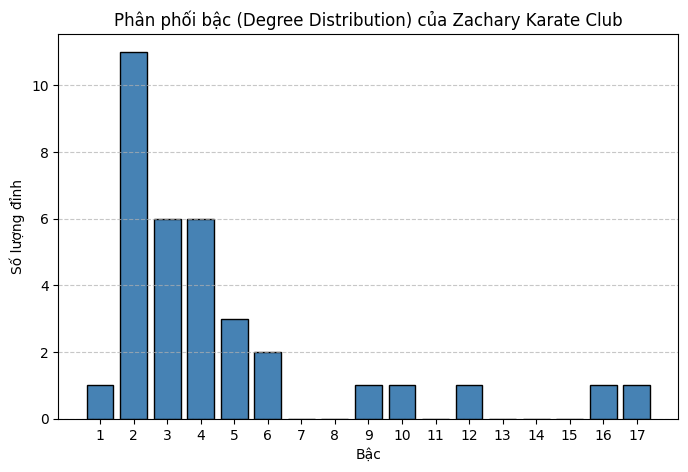

Đỉnh mang bậc lớn nhất (chỉ số bắt đầu từ 0): [33]


In [5]:
# Lấy danh sách bậc của tất cả các đỉnh trong đồ thị
danh_sach_bac = g.degree()

# Vẽ histogram
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    danh_sach_bac,
    bins=range(min(danh_sach_bac), max(danh_sach_bac) + 2),
    align='left',
    rwidth=0.8,
    color='steelblue',
    edgecolor='black'
)

ax.set_title("Phân phối bậc (Degree Distribution) của Zachary Karate Club")
ax.set_xlabel("Bậc")
ax.set_ylabel("Số lượng đỉnh")
plt.xticks(range(min(danh_sach_bac), max(danh_sach_bac) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Trả lời câu hỏi
bac_lon_nhat = max(danh_sach_bac)
dinh_bac_max = [i for i, bac in enumerate(danh_sach_bac) if bac == bac_lon_nhat]

print(f"Đỉnh mang bậc lớn nhất (chỉ số bắt đầu từ 0): {dinh_bac_max}")

Vì: Zachary Karate Club ghi lại các mối quan hệ giao tiếp và tình bạn bên ngoài võ đường của một câu lạc bộ karate tại trường đại học. Trong cấu trúc đó, đỉnh 34 đại diện cho chủ tịch câu lạc bộ, là người phải tương tác thường xuyên với hầu hết các hội viên, khiến mạng lưới của người này mở rộng một cách tự nhiên so với những thành viên thông thường.

1.4. Vẽ đồ thị Zachary

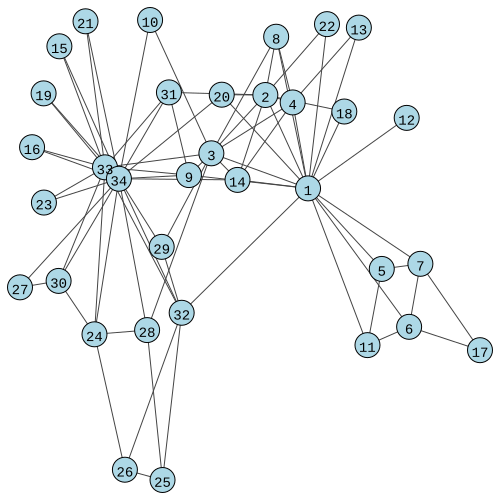

In [6]:
random.seed(42)

# Khởi tạo thuật toán bố trí Fruchterman-Reingold mà không sử dụng tham số seed bên trong
layout = g.layout_fruchterman_reingold()

do_thi = ig.plot(
    g,
    layout=layout,
    vertex_label=[i+1 for i in range(g.vcount())],
    vertex_size=25,
    vertex_color="lightblue",
    bbox=(500, 500)
)

do_thi

### 2 — Mật độ và Modularity

2.1. Mật độ đồ thị (graph density)

In [7]:
# Trích xuất số lượng đỉnh và cạnh
n = g.vcount()
m = g.ecount()

mat_do_thu_cong = m/(n*(n-1)/2)

# Trích xuất chỉ số mật độ từ hàm tích hợp sẵn của python-igraph để đối chiếu
mat_do_thu_vien = g.density()

# Kết quả
print(f"Mật độ tính thủ công: {mat_do_thu_cong:.4f}")
print(f"Mật độ kiểm chứng bằng g.density(): {mat_do_thu_vien:.4f}")

Mật độ tính thủ công: 0.1390
Mật độ kiểm chứng bằng g.density(): 0.1390


2.2. Modularity của một phân hoạch tuỳ ý

In [8]:
# Khởi tạo mảng nhãn cộng đồng theo phương pháp phân chia cơ học
membership_naive = [0] * 17 + [1] * 17

# Tính toán Modularity trên đồ thị gốc
Q_naive = g.modularity(membership_naive)

# Kết quả
print(f"Chỉ số Modularity Q: {Q_naive:.4f}")

Chỉ số Modularity Q: 0.2433


2.3. Internal vs external density

In [9]:
def danh_gia_mat_do_cong_dong(g, membership):
    # Lấy mật độ toàn cục của đồ thị
    p = g.density()
    n = g.vcount()
    print(f"Mật độ toàn cục: {p:.4f}\n")

    # Lấy danh sách các cộng đồng duy nhất
    cac_cong_dong = set(membership)

    for cong_dong in cac_cong_dong:
        # Lọc ra danh sách các đỉnh thuộc cộng đồng hiện tại
        dinh_trong_cụm = [v.index for v in g.vs if membership[v.index] == cong_dong]
        n_s = len(dinh_trong_cụm)

        if n_s < 2:
            print(f"Cộng đồng {cong_dong} có quá ít đỉnh để tính toán.\n")
            continue

        m_s = 0     # Số cạnh bên trong cộng đồng
        m_ext = 0   # Số cạnh nối ra bên ngoài

        # Duyệt qua từng đỉnh trong cộng đồng để đếm cạnh
        for u in dinh_trong_cụm:
            cac_lang_gieng = g.neighbors(u)
            for v in cac_lang_gieng:
                if membership[v] == cong_dong:
                    m_s += 1
                else:
                    m_ext += 1

        m_s = m_s // 2

        # Tính các chỉ số mật độ
        delta_int = m_s / (n_s * (n_s - 1) / 2)
        delta_ext = m_ext / (n_s * (n - n_s))

        print(f"--- Cộng đồng {cong_dong} ---")
        print(f"Số đỉnh: {n_s}, Số cạnh nội: {m_s}, Số cạnh ngoại: {m_ext}")
        print(f"Mật độ nội bộ: {delta_int:.4f}")
        print(f"Mật độ ngoại bộ: {delta_ext:.4f}")

        # Kiểm tra điều kiện cluster
        thoa_man = (delta_int > p) and (delta_ext < p)
        trang_thai = "Có" if thoa_man else "Không"
        print(f"Thỏa mãn điều kiện cluster (δ_int > p và δ_ext < p): {trang_thai}\n")

danh_gia_mat_do_cong_dong(g, membership_naive)

Mật độ toàn cục: 0.1390

--- Cộng đồng 0 ---
Số đỉnh: 17, Số cạnh nội: 30, Số cạnh ngoại: 20
Mật độ nội bộ: 0.2206
Mật độ ngoại bộ: 0.0692
Thỏa mãn điều kiện cluster (δ_int > p và δ_ext < p): Có

--- Cộng đồng 1 ---
Số đỉnh: 17, Số cạnh nội: 28, Số cạnh ngoại: 20
Mật độ nội bộ: 0.2059
Mật độ ngoại bộ: 0.0692
Thỏa mãn điều kiện cluster (δ_int > p và δ_ext < p): Có



### Phần 3 — Thuật toán Edge Betweenness

 3.1. Chạy thuật toán Newman–Girvan

In [10]:
# Thực thi thuật toán Edge Betweenness trên đồ thị vô hướng
dendro_eb = g.community_edge_betweenness(directed=False)

# Cắt dendrogram ở mức tối ưu nhất (nơi giá trị Modularity đạt đỉnh) để lấy danh sách các cụm
clusters_eb = dendro_eb.as_clustering()

# Kết quả
print('Số cộng đồng:', len(clusters_eb))
print('Modularity:', g.modularity(clusters_eb.membership))

Số cộng đồng: 5
Modularity: 0.40129848783694944


3.2. Vẽ kết quả phân cụm

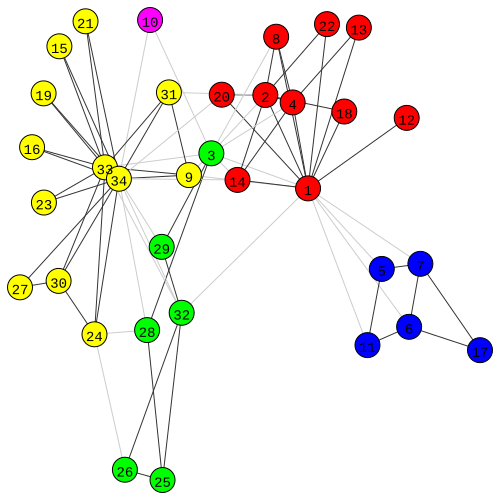

In [22]:
# Vẽ đồ thị phân cụm, tự động tô màu theo cộng đồng và lưu thành file
do_thi_eb = ig.plot(
    clusters_eb,
    layout=layout,
    vertex_label=[i+1 for i in range(g.vcount())],
    vertex_size=25,
    target='zachary_edge_betweenness.png',
    bbox=(500, 500)
)

do_thi_eb

3.3. Vẽ dendrogram

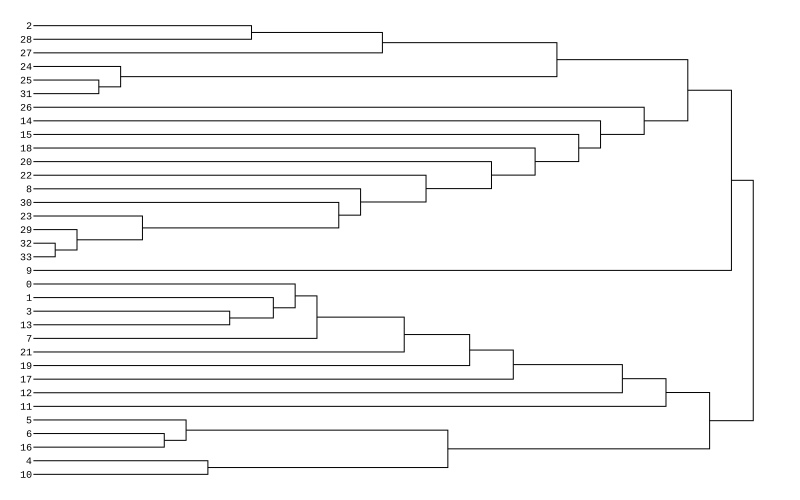

In [12]:
# Khởi tạo quá trình vẽ dendrogram từ đối tượng dendro_eb đã có ở Câu 3.1
do_thi_dendrogram = ig.plot(
    dendro_eb,
    bbox=(800, 500)
)

do_thi_dendrogram

 3.4. Modularity theo số cụm

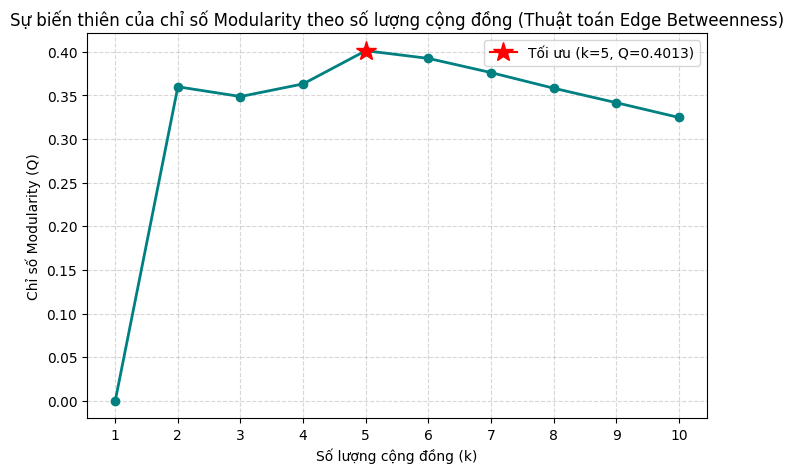

Dựa trên đồ thị, số lượng cụm tối ưu nhất là k = 5 với chỉ số Modularity đạt đỉnh Q = 0.4013.


In [13]:
# Khởi tạo các danh sách để lưu trữ giá trị k và Modularity
danh_sach_k = range(1, 11)
danh_sach_Q = []

# Vòng lặp các giá trị k từ 1 đến 10
for k in danh_sach_k:
    # Cắt dendrogram để ép thuật toán tạo ra chính xác k cộng đồng
    clusters_k = dendro_eb.as_clustering(n=k)

    # Tính toán chỉ số Modularity cho phân hoạch này
    Q = g.modularity(clusters_k.membership)
    danh_sach_Q.append(Q)

# Trực quan hóa sự biến thiên của Modularity
fig, ax = plt.subplots(figsize=(8, 5))

# Vẽ đường biểu diễn Q theo k
ax.plot(danh_sach_k, danh_sach_Q, marker='o', linestyle='-', color='teal', linewidth=2)

# Đánh dấu điểm có Modularity cao nhất
Q_max = max(danh_sach_Q)
k_toi_uu = danh_sach_k[danh_sach_Q.index(Q_max)]
ax.plot(k_toi_uu, Q_max, marker='*', markersize=15, color='red', label=f'Tối ưu (k={k_toi_uu}, Q={Q_max:.4f})')

ax.set_title("Sự biến thiên của chỉ số Modularity theo số lượng cộng đồng (Thuật toán Edge Betweenness)")
ax.set_xlabel("Số lượng cộng đồng (k)")
ax.set_ylabel("Chỉ số Modularity (Q)")
ax.set_xticks(danh_sach_k)
ax.grid(axis='both', linestyle='--', alpha=0.5)
ax.legend()

plt.show()

# Kết luận
print(f"Dựa trên đồ thị, số lượng cụm tối ưu nhất là k = {k_toi_uu} với chỉ số Modularity đạt đỉnh Q = {Q_max:.4f}.")

### Phần 4 — Thuật toán Louvain

4.1. Chạy Louvain (multilevel)

In [14]:
# Thuật toán Louvain (Multilevel)
clusters_louvain = g.community_multilevel()

# Trích xuất và in số lượng cộng đồng tìm được
so_cong_dong_louvain = len(clusters_louvain)
print(f"Số cộng đồng: {so_cong_dong_louvain}")

# Tính toán và in chỉ số Modularity
modularity_louvain = g.modularity(clusters_louvain.membership)
print(f"Modularity: {modularity_louvain:.4f}")

Số cộng đồng: 4
Modularity: 0.4188


4.2. Vẽ kết quả

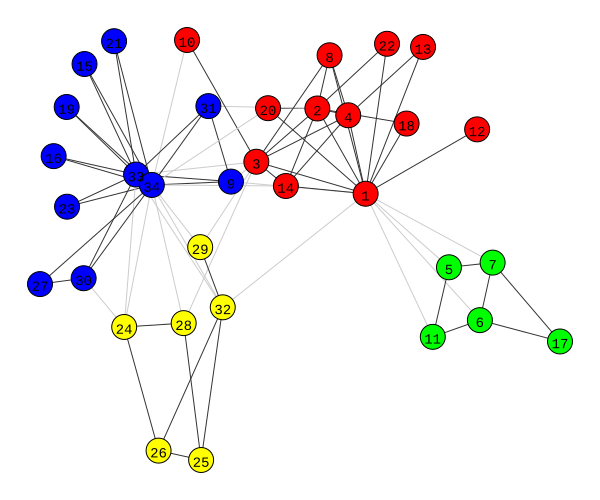

In [15]:
# Trực quan hóa phân hoạch của thuật toán Louvain
do_thi_louvain = ig.plot(
    clusters_louvain,
    layout=layout,
    vertex_label=[i+1 for i in range(g.vcount())],
    vertex_size=25,
    target='zachary_louvain.png',
    bbox=(600, 500),
    margin=40
)

do_thi_louvain

4.3. So sánh modularity

In [16]:
# Tính toán độ chênh lệch tuyệt đối giữa hai chỉ số
do_chenh_lech = modularity_louvain - g.modularity(clusters_eb.membership)

print(f"Modularity của Louvain: {modularity_louvain:.4f}")
print(f"Modularity của Edge Betweenness: {g.modularity(clusters_eb.membership):.4f}")
print(f"Mức độ chênh lệch (Louvain - EB): {do_chenh_lech:.4f}")

if do_chenh_lech > 0:
    print("-> Kết luận: Thuật toán Louvain cho kết quả Modularity cao hơn.")
else:
    print("-> Kết luận: Thuật toán Edge Betweenness cho kết quả Modularity cao hơn (Hiếm gặp).")

Modularity của Louvain: 0.4188
Modularity của Edge Betweenness: 0.4013
Mức độ chênh lệch (Louvain - EB): 0.0175
-> Kết luận: Thuật toán Louvain cho kết quả Modularity cao hơn.


### 5 — Thuật toán Walktrap

5.1. Chạy Walktrap với độ dài bước t=4

In [17]:
# Tthuật toán Walktrap trên đồ thị
dendro_wt = g.community_walktrap(steps=4)

# Chuyển đổi biểu đồ phân cấp thành phân hoạch cụm tối ưu
clusters_wt = dendro_wt.as_clustering()

# Trích xuất số lượng cộng đồng và tính toán Modularity
so_cong_dong_wt = len(clusters_wt)
modularity_wt = g.modularity(clusters_wt.membership)

# Kết quả
print(f"Số lượng cộng đồng phát hiện được: {so_cong_dong_wt}")
print(f"Chỉ số Modularity Q: {modularity_wt:.4f}")

Số lượng cộng đồng phát hiện được: 5
Chỉ số Modularity Q: 0.3532


Câu 5.2. Thí nghiệm với các giá trị t khác nhau

Bước t = 2: Số cộng đồng = 4, Modularity Q = 0.4198
Bước t = 3: Số cộng đồng = 4, Modularity Q = 0.4198
Bước t = 4: Số cộng đồng = 5, Modularity Q = 0.3532
Bước t = 5: Số cộng đồng = 3, Modularity Q = 0.3944
Bước t = 6: Số cộng đồng = 3, Modularity Q = 0.3944
Bước t = 8: Số cộng đồng = 4, Modularity Q = 0.3752


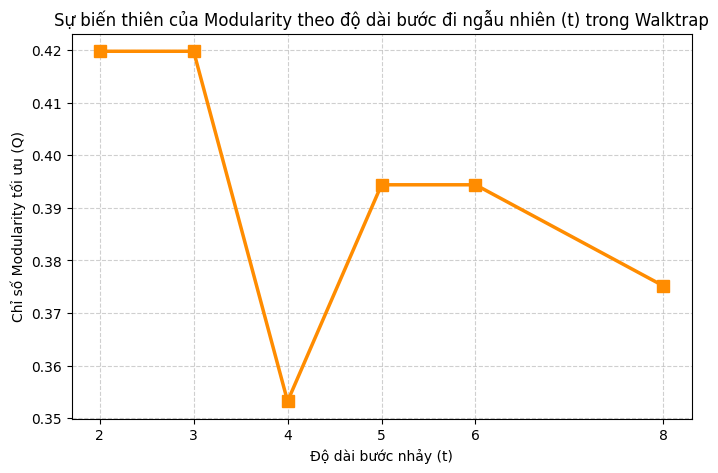

In [18]:
# Khởi tạo danh sách các tham số t cần thí nghiệm và mảng lưu kết quả
danh_sach_t = [2, 3, 4, 5, 6, 8]
danh_sach_Q_wt = []

for t in danh_sach_t:
    # Chạy Walktrap với độ dài bước tương ứng
    dendro_t = g.community_walktrap(steps=t)

    # Cắt cây phân cấp ở mức tối ưu nhất
    clusters_t = dendro_t.as_clustering()

    # Tính Modularity và lưu vào mảng
    Q_t = g.modularity(clusters_t.membership)
    danh_sach_Q_wt.append(Q_t)

    print(f"Bước t = {t}: Số cộng đồng = {len(clusters_t)}, Modularity Q = {Q_t:.4f}")

# rực quan hóa sự biến thiên của Modularity theo t
fig, ax = plt.subplots(figsize=(8, 5))

# Vẽ đường biểu diễn
ax.plot(danh_sach_t, danh_sach_Q_wt, marker='s', color='darkorange', linewidth=2.5, markersize=8)

# Tùy chỉnh nhãn và tiêu đề biểu đồ
ax.set_title("Sự biến thiên của Modularity theo độ dài bước đi ngẫu nhiên (t) trong Walktrap")
ax.set_xlabel("Độ dài bước nhảy (t)")
ax.set_ylabel("Chỉ số Modularity tối ưu (Q)")
ax.set_xticks(danh_sach_t)
ax.grid(axis='both', linestyle='--', alpha=0.6)

plt.show()

 5.3. Vẽ kết quả phân cụm

-> Tham số tối ưu được chọn: t = 2 (với Q = 0.4198)


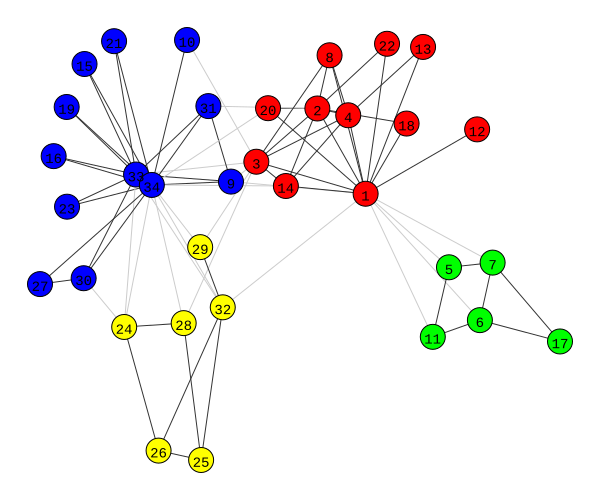

In [19]:
Q_max_wt = max(danh_sach_Q_wt)
vi_tri_max = danh_sach_Q_wt.index(Q_max_wt)
t_toi_uu = danh_sach_t[vi_tri_max]

print(f"-> Tham số tối ưu được chọn: t = {t_toi_uu} (với Q = {Q_max_wt:.4f})")

# Lấy đối tượng phân hoạch tương ứng với t tối ưu
dendro_wt_toi_uu = g.community_walktrap(steps=t_toi_uu)
clusters_wt_toi_uu = dendro_wt_toi_uu.as_clustering()

# Trực quan hóa kết quả
do_thi_wt = ig.plot(
    clusters_wt_toi_uu,
    layout=layout,
    vertex_label=[i+1 for i in range(g.vcount())],
    vertex_size=25,
    target='zachary_walktrap.png',
    bbox=(600, 500),
    margin=40
)

# Hiển thị đồ thị trực tiếp
do_thi_wt

### 6 — Tổng hợp và Thảo luận

6.1. Bảng so sánh

In [20]:
import time

# Đánh giá thuật toán Edge Betweenness (Newman-Girvan)
start_eb = time.perf_counter()
dendro_eb = g.community_edge_betweenness(directed=False)
clusters_eb = dendro_eb.as_clustering()
end_eb = time.perf_counter()

time_eb = end_eb - start_eb
n_eb = len(clusters_eb)
q_eb = g.modularity(clusters_eb.membership)

# Đánh giá thuật toán Louvain (Fast Community Unfolding)
start_louvain = time.perf_counter()
clusters_louvain = g.community_multilevel()
end_louvain = time.perf_counter()

time_louvain = end_louvain - start_louvain
n_louvain = len(clusters_louvain)
q_louvain = g.modularity(clusters_louvain.membership)

# Đánh giá thuật toán Walktrap (t = 4)
start_wt = time.perf_counter()
dendro_wt = g.community_walktrap(steps=4)
clusters_wt = dendro_wt.as_clustering()
end_wt = time.perf_counter()

time_wt = end_wt - start_wt
n_wt = len(clusters_wt)
q_wt = g.modularity(clusters_wt.membership)

# In bảng kết quả so sánh
print("="*75)
print(f"{'Thuật toán':<25} | {'Số cộng đồng':<15} | {'Modularity Q':<15} | {'Thời gian chạy (s)':<15}")
print("-" * 75)
print(f"{'Edge Betweenness':<25} | {n_eb:<15} | {q_eb:<15.4f} | {time_eb:<15.6f}")
print(f"{'Louvain':<25} | {n_louvain:<15} | {q_louvain:<15.4f} | {time_louvain:<15.6f}")
print(f"{'Walktrap (t=4)':<25} | {n_wt:<15} | {q_wt:<15.4f} | {time_wt:<15.6f}")
print("="*75)

Thuật toán                | Số cộng đồng    | Modularity Q    | Thời gian chạy (s)
---------------------------------------------------------------------------
Edge Betweenness          | 5               | 0.4013          | 0.006104       
Louvain                   | 4               | 0.4151          | 0.000329       
Walktrap (t=4)            | 5               | 0.3532          | 0.000517       


6.2. Đối chiếu với phân hoạch thực tế

In [21]:
from sklearn.metrics import normalized_mutual_info_score

# Khởi tạo mảng phân hoạch thực tế (Ground Truth) do Zachary ghi nhận
truth = [0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1]

# Trích xuất mảng nhãn dự đoán từ kết quả của thuật toán Louvain
nhan_du_doan_louvain = clusters_louvain.membership

# Tiến hành đo lường mức độ tương đồng bằng Normalized Mutual Information (NMI)
nmi_louvain = normalized_mutual_info_score(truth, nhan_du_doan_louvain)

# Kết quả đánh giá
print(f"Chỉ số Normalized Mutual Information (NMI): {nmi_louvain:.4f}")

Chỉ số Normalized Mutual Information (NMI): 0.7071
